# Name: Abhishek Harmalkar | Roll no:28 | SE AIML | ML LAB EXP 6
# Classification of Credit Card Default Risk using Support Vector Machine

In [54]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix


In [55]:
data=pd.read_csv("/content/credit - credit.csv",skiprows=1)
data=data.sample(5000,random_state=42)

print(data.columns)

data.drop(columns=['ID'],inplace=True)
print(data.columns)

Index(['ID', 'LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')
Index(['LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')


In [56]:
data.tail(5)

,LIMIT_BAL,GENDER,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
6778,180000,1,1,2,27,0,0,0,0,0,...,16908,37319,34978,19000,5000,10009,22000,20000,15000,0
25284,50000,2,2,2,22,0,0,0,0,0,...,52198,43181,31473,2000,2000,10052,2000,1136,2000,0
18355,200000,2,1,2,24,-2,-2,-2,-2,-2,...,500,2057,23322,1053,0,500,2057,23322,4299,0
27684,120000,2,2,2,24,0,0,0,0,0,...,53216,49194,48487,2000,2600,4241,1700,2500,1500,0
4110,90000,2,2,1,29,0,0,0,0,0,...,4173,4408,5846,1522,3010,1500,1500,1500,2000,0


In [57]:
data.isnull().sum()

,0
LIMIT_BAL,0
GENDER,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0
PAY_5,0


In [58]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 2308 to 4110
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   5000 non-null   int64
 1   GENDER                      5000 non-null   int64
 2   EDUCATION                   5000 non-null   int64
 3   MARRIAGE                    5000 non-null   int64
 4   AGE                         5000 non-null   int64
 5   PAY_0                       5000 non-null   int64
 6   PAY_2                       5000 non-null   int64
 7   PAY_3                       5000 non-null   int64
 8   PAY_4                       5000 non-null   int64
 9   PAY_5                       5000 non-null   int64
 10  PAY_6                       5000 non-null   int64
 11  BILL_AMT1                   5000 non-null   int64
 12  BILL_AMT2                   5000 non-null   int64
 13  BILL_AMT3                   5000 non-null   int64
 14  BILL_AMT4 

In [59]:
data.head(5)

,LIMIT_BAL,GENDER,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
2308,30000,1,2,2,25,0,0,0,0,0,...,12580,13716,14828,1500,2000,1500,1500,1500,2000,0
22404,150000,2,1,2,26,0,0,0,0,0,...,101581,77741,77264,4486,4235,3161,2647,2669,2669,0
23397,70000,2,3,1,32,0,0,0,0,0,...,69753,70111,70212,2431,3112,3000,2438,2500,2554,0
25058,130000,1,3,2,49,0,0,0,0,0,...,16898,11236,6944,1610,1808,7014,27,7011,4408,0
2664,50000,2,2,2,36,0,0,0,0,0,...,19574,20295,19439,2000,1500,1000,1800,0,1000,1


In [60]:
y=data['default payment next month']
x=data[['BILL_AMT1','BILL_AMT2']]

print(x.dtypes)
print(x.head())

BILL_AMT1    int64
BILL_AMT2    int64
dtype: object
       BILL_AMT1  BILL_AMT2
2308        8864      10062
22404     136736     125651
23397      70122      69080
25058      20678      18956
2664       94228      47635


In [61]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.3,random_state=42)

In [62]:
scaler=StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [63]:
models = {
    "Linear SVM ": SVC(kernel='linear', C= 1, class_weight='balanced'),
    "Polynomial SVM" : SVC (kernel='poly',
                           degree=2,
                            C=1,gamma='scale',
                            class_weight='balanced'
                        ),

    "RBF SVM" : SVC(kernel = 'rbf',
                    C=5,
                    gamma = 0.1,
                    class_weight = 'balanced'

                   )
}

for name, model in models.items():
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    y_pred_train=model.predict(x_train)
    print("\n",name)
    print("Confusion Matrix;",confusion_matrix(y_test,y_pred))
    print("precision score:",precision_score(y_test,y_pred, zero_division=0))
    print("recall score:",recall_score(y_test,y_pred))
    print("f1 score:",f1_score(y_test,y_pred))
    print("Accuracy train score:",accuracy_score(y_test,y_pred))
    print("Accuracy test score:",accuracy_score(y_train,y_pred_train))


 Linear SVM 
Confusion Matrix; [[ 103 1056]
 [  34  307]]
precision score: 0.2252384446074835
recall score: 0.9002932551319648
f1 score: 0.36032863849765256
Accuracy train score: 0.2733333333333333
Accuracy test score: 0.2797142857142857

 Polynomial SVM
Confusion Matrix; [[  35 1124]
 [   8  333]]
precision score: 0.22855181880576528
recall score: 0.9765395894428153
f1 score: 0.3704115684093437
Accuracy train score: 0.24533333333333332
Accuracy test score: 0.24114285714285713

 RBF SVM
Confusion Matrix; [[560 599]
 [166 175]]
precision score: 0.22609819121447028
recall score: 0.5131964809384164
f1 score: 0.31390134529147984
Accuracy train score: 0.49
Accuracy test score: 0.5017142857142857


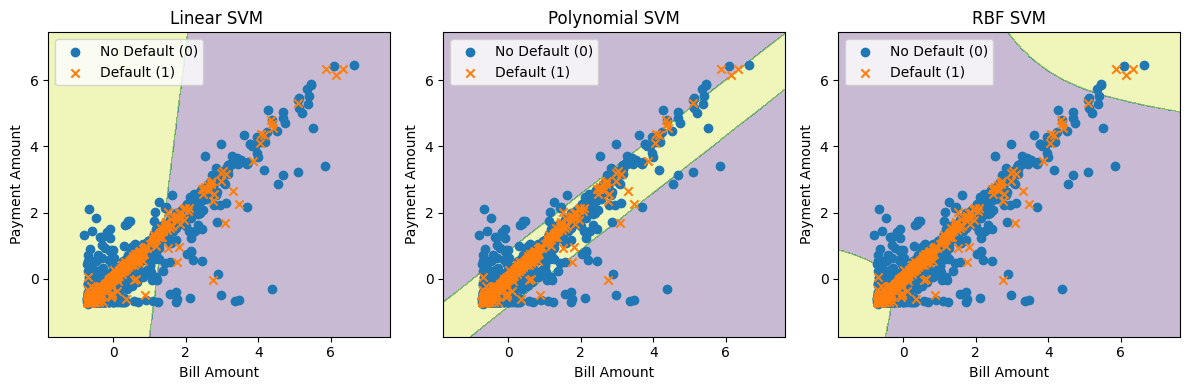

In [64]:
def plot_boundary(model, title):
    h = 0.02

    x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
    y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)


    plt.scatter(
        x_train[y_train == 0, 0],
        x_train[y_train == 0, 1],
        label='No Default (0)',
        marker='o'
    )


    plt.scatter(
        x_train[y_train == 1, 0],
        x_train[y_train == 1, 1],
        label='Default (1)',
        marker='x'
    )

    plt.legend()
    plt.title(title)
    plt.xlabel("Bill Amount")
    plt.ylabel("Payment Amount")


plt.figure(figsize=(12, 4))

for i, (name, model) in enumerate(models.items()):
    plt.subplot(1, 3, i + 1)
    model.fit(x_train, y_train)
    plot_boundary(model, name)

plt.tight_layout()
plt.show()
